# Load and Prepare Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving SP1.csv to SP1.csv


In [3]:
df = pd.read_csv("SP1.csv")


In [4]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Columns: 131 entries, Div to BFECAHA
dtypes: float64(108), int64(16), object(7)
memory usage: 389.0+ KB


,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFECAHH,BFECAHA
0,SP1,15/08/2025,18:00,Girona,Vallecano,1,3,A,0,3,...,2.1,1.78,1.97,1.95,2.10,1.80,1.95,1.75,2.11,1.89
1,SP1,15/08/2025,20:30,Villarreal,Oviedo,2,0,H,2,0,...,1.9,1.95,1.93,2.00,1.94,1.96,1.82,1.87,1.96,2.02
2,SP1,16/08/2025,18:30,Mallorca,Barcelona,0,3,A,0,2,...,2.0,1.85,1.88,2.05,2.00,1.93,1.90,1.86,2.04,1.94
3,SP1,16/08/2025,20:30,Alaves,Levante,2,1,H,1,0,...,1.8,2.05,1.86,2.07,1.80,2.07,1.70,2.00,1.81,2.20
4,SP1,16/08/2025,20:30,Valencia,Sociedad,1,1,D,0,0,...,2.1,1.78,2.13,1.81,2.10,1.78,1.96,1.74,2.18,1.84


# Check missing values

In [5]:
df.isnull().sum()

,0
Div,0
Date,0
Time,0
HomeTeam,0
AwayTeam,0
...,...
MaxCAHA,0
AvgCAHH,0
AvgCAHA,0
BFECAHH,31


# Remove duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

# Focus analysis columns

In [6]:
analysis_df = df[
    [
        "Div",
        "Date",
        "HomeTeam",
        "AwayTeam",
        "FTHG",
        "FTAG",
        "FTR",
        "BMGMH",
        "BMGMD",
        "BMGMA"
    ]
]

In [7]:
analysis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Div       380 non-null    object 
 1   Date      380 non-null    object 
 2   HomeTeam  380 non-null    object 
 3   AwayTeam  380 non-null    object 
 4   FTHG      380 non-null    int64  
 5   FTAG      380 non-null    int64  
 6   FTR       380 non-null    object 
 7   BMGMH     378 non-null    float64
 8   BMGMD     378 non-null    float64
 9   BMGMA     378 non-null    float64
dtypes: float64(3), int64(2), object(5)
memory usage: 29.8+ KB


# Data Description
| Column     | Data Type | Description                                                   |
| ---------- | --------- | ------------------------------------------------------------- |
| `Div`      | object    | League division identifier                                    |
| `Date`     | object    | Match date                                                    |
| `HomeTeam` | object    | Name of the home team                                         |
| `AwayTeam` | object    | Name of the away team                                         |
| `FTHG`     | int64     | Full-Time Home Goals scored                                   |
| `FTAG`     | int64     | Full-Time Away Goals scored                                   |
| `FTR`      | object    | Full-Time Result (`H` = Home Win, `D` = Draw, `A` = Away Win) |
| `BMGMH`    | float64   | BetMGM odds for Home Win                                      |
| `BMGMD`    | float64   | BetMGM odds for Draw                                          |
| `BMGMA`    | float64   | BetMGM odds for Away Win                                      |


Betfair Exchange and Bet365 odds were excluded from the main analysis due to substantial missing values, which could reduce statistical reliability

In [8]:
analysis_df[analysis_df["BMGMH"].isnull()]

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,BMGMH,BMGMD,BMGMA
332,SP1,02/05/2026,Valencia,Ath Madrid,0,2,A,NaN,NaN,NaN
341,SP1,09/05/2026,Elche,Alaves,1,1,D,NaN,NaN,NaN


In [9]:
analysis_df = analysis_df.dropna(
    subset=["BMGMH", "BMGMD", "BMGMA"]
)

In [10]:
analysis_df.info()
analysis_df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 378 entries, 0 to 379
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Div       378 non-null    object 
 1   Date      378 non-null    object 
 2   HomeTeam  378 non-null    object 
 3   AwayTeam  378 non-null    object 
 4   FTHG      378 non-null    int64  
 5   FTAG      378 non-null    int64  
 6   FTR       378 non-null    object 
 7   BMGMH     378 non-null    float64
 8   BMGMD     378 non-null    float64
 9   BMGMA     378 non-null    float64
dtypes: float64(3), int64(2), object(5)
memory usage: 32.5+ KB


,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,BMGMH,BMGMD,BMGMA
0,SP1,15/08/2025,Girona,Vallecano,1,3,A,2.17,3.25,3.25
1,SP1,15/08/2025,Villarreal,Oviedo,2,0,H,1.34,5.00,7.50
2,SP1,16/08/2025,Mallorca,Barcelona,0,3,A,7.00,4.90,1.38
3,SP1,16/08/2025,Alaves,Levante,2,1,H,2.16,3.05,3.55
4,SP1,16/08/2025,Valencia,Sociedad,1,1,D,2.50,2.85,3.00


# Question 1: Which Teams Consistently Outperform Bookmaker Expectations?

# Market Expectation
convert odds → probabilities:

In [11]:
df["home_prob"] = 1 / df["BMGMH"]
df["draw_prob"] = 1 / df["BMGMD"]
df["away_prob"] = 1 / df["BMGMA"]

In [12]:
total = df["home_prob"] + df["draw_prob"] + df["away_prob"]

df["home_prob"] /= total
df["draw_prob"] /= total
df["away_prob"] /= total

# Actual Outcome Encoding

In [13]:
df["actual_home_win"] = (df["FTR"] == "H").astype(int)
df["actual_draw"] = (df["FTR"] == "D").astype(int)
df["actual_away_win"] = (df["FTR"] == "A").astype(int)

# Overperformance Score

In [14]:
df["home_overperf"] = df["actual_home_win"] - df["home_prob"]
df["away_overperf"] = df["actual_away_win"] - df["away_prob"]

# Aggregate by team

In [15]:
home = df.groupby("HomeTeam")["home_overperf"].mean()
away = df.groupby("AwayTeam")["away_overperf"].mean()

In [17]:
team_overperf = home + away
team_overperf = team_overperf.sort_values(ascending=False)

# Top overperforming teams:

In [18]:
team_overperf.head(10)

,0
HomeTeam,
Barcelona,0.282435
Villarreal,0.268593
Getafe,0.219681
Real Madrid,0.136639
Valencia,0.070091
Levante,0.062875
Mallorca,0.025253
Alaves,0.002017
Elche,-0.002990


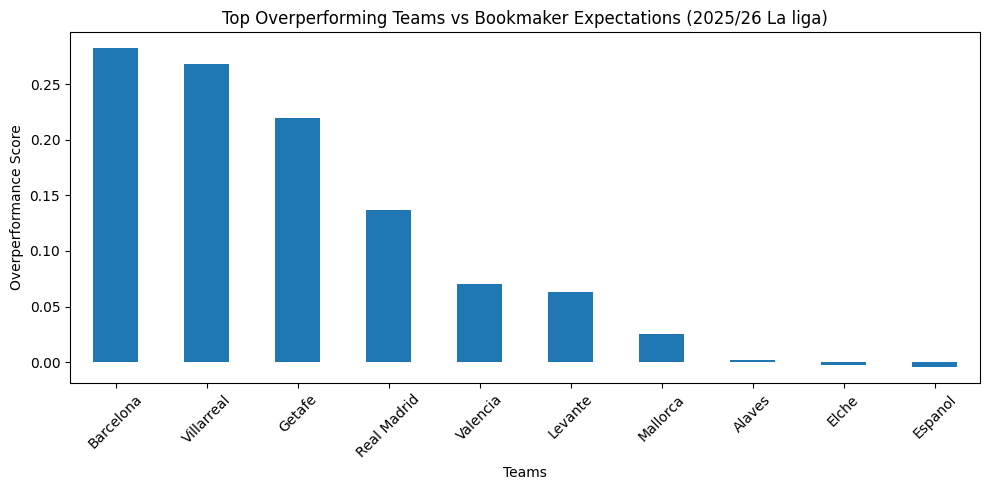

In [19]:
import matplotlib.pyplot as plt

top_over = team_overperf.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_over.plot(kind="bar")

plt.title("Top Overperforming Teams vs Bookmaker Expectations (2025/26 La liga)")
plt.xlabel("Teams")
plt.ylabel("Overperformance Score")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Worst performing teams:

In [20]:
team_overperf.tail(10)

,0
HomeTeam,
Sevilla,-0.009890
Betis,-0.010603
Celta,-0.012161
Ath Madrid,-0.013760
Vallecano,-0.038539
Osasuna,-0.071287
Oviedo,-0.120853
Girona,-0.137502
Ath Bilbao,-0.161038


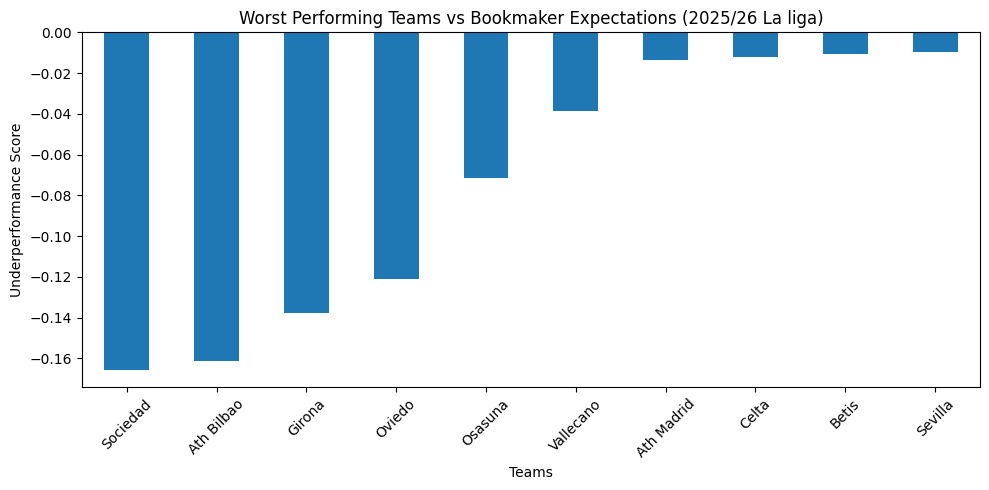

In [22]:
bottom_over = team_overperf.sort_values(ascending=True).head(10)

plt.figure(figsize=(10,5))
bottom_over.plot(kind="bar")

plt.title("Worst Performing Teams vs Bookmaker Expectations (2025/26 La liga)")
plt.xlabel("Teams")
plt.ylabel("Underperformance Score")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

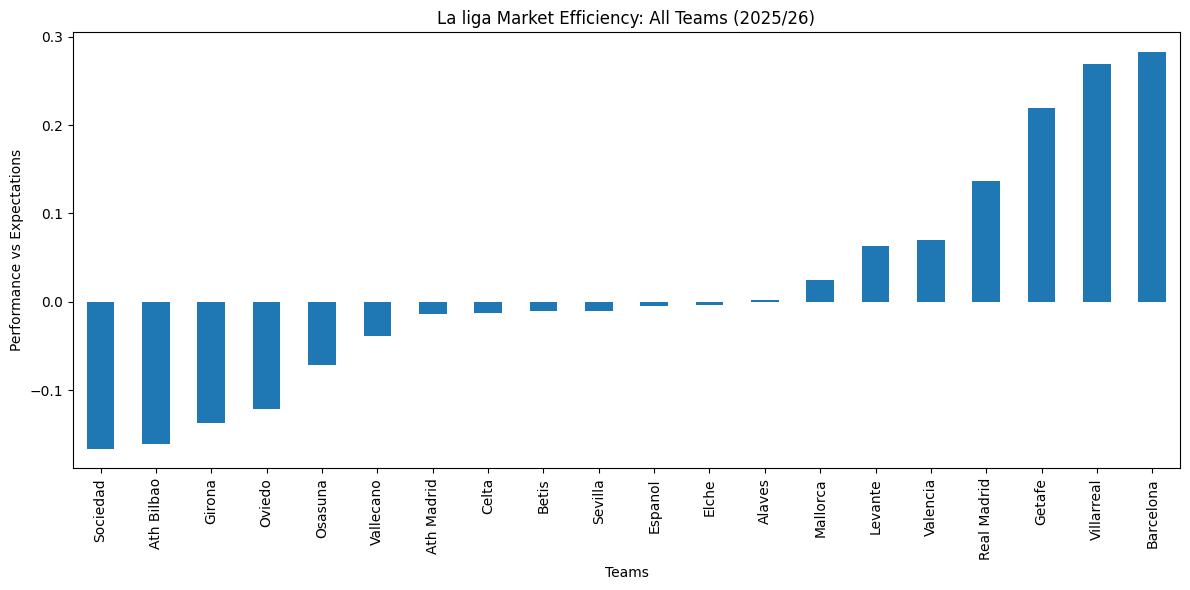

In [24]:
plt.figure(figsize=(12,6))
team_overperf.sort_values().plot(kind="bar")

plt.title("La liga Market Efficiency: All Teams (2025/26)")
plt.xlabel("Teams")
plt.ylabel("Performance vs Expectations")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Question 2: Which Odds Ranges Produce the Highest Number of Upsets?

# Create Favorite Team

In [29]:
import numpy as np

analysis_df["Favorite"] = np.where(
    analysis_df["BMGMH"] < analysis_df["BMGMA"],
    "Home",
    "Away"
)

# Create Favorite_Won Column

In [30]:
analysis_df["Favorite_Won"] = (
    ((analysis_df["Favorite"] == "Home") & (analysis_df["FTR"] == "H")) |
    ((analysis_df["Favorite"] == "Away") & (analysis_df["FTR"] == "A"))
)

# Create Upset Column

In [31]:
analysis_df["Upset"] = ~analysis_df["Favorite_Won"]

In [32]:
upset_analysis = (
    analysis_df.groupby("Odds_Range", observed=False)
    .agg(
        Matches=("Upset", "count"),
        Upsets=("Upset", "sum")
    )
)

upset_analysis["Upset_Rate"] = (
    upset_analysis["Upsets"] /
    upset_analysis["Matches"]
)

upset_analysis

,Matches,Upsets,Upset_Rate
Odds_Range,,,
1.0–1.5,70,13,0.185714
1.5–2.0,119,52,0.436975
2.0–2.5,159,87,0.547170
2.5–3.0,30,20,0.666667
3.0+,0,0,NaN


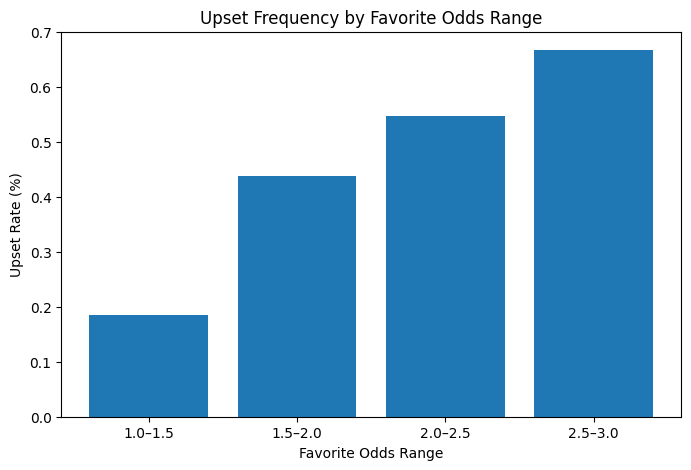

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    upset_analysis.index.astype(str),
    upset_analysis["Upset_Rate"]
)

plt.title("Upset Frequency by Favorite Odds Range")
plt.xlabel("Favorite Odds Range")
plt.ylabel("Upset Rate (%)")

plt.show()

# Question 3: Which Teams Are Most Reliable at Home According to Bookmaker Expectations?

# Identify Home Favorites

In [34]:
analysis_df["Home_Favorite"] = (
    analysis_df["BMGMH"] < analysis_df["BMGMA"]
)

# Identify Successful Home Favorites

In [35]:
analysis_df["Home_Favorite_Win"] = (
    (analysis_df["Home_Favorite"]) &
    (analysis_df["FTR"] == "H")
)

# Aggregate by Team

In [36]:
home_analysis = (
    analysis_df.groupby("HomeTeam")
    .agg(
        Home_Favorite_Matches=("Home_Favorite", "sum"),
        Home_Favorite_Wins=("Home_Favorite_Win", "sum")
    )
)

home_analysis["Home_Conversion_Rate"] = (
    home_analysis["Home_Favorite_Wins"] /
    home_analysis["Home_Favorite_Matches"]
)

home_analysis.sort_values(
    "Home_Conversion_Rate",
    ascending=False
)

,Home_Favorite_Matches,Home_Favorite_Wins,Home_Conversion_Rate
HomeTeam,,,
Barcelona,19,19,1.000000
Levante,7,7,1.000000
Villarreal,17,15,0.882353
Real Madrid,19,16,0.842105
Ath Madrid,17,14,0.823529
Elche,9,7,0.777778
Betis,15,10,0.666667
Mallorca,12,7,0.583333
Osasuna,14,8,0.571429


# Question 4: Are Bookmakers More Accurate at Predicting Home Wins, Draws, or Away Wins?

# Identify Bookmaker Favorite

In [37]:
analysis_df["Predicted_Result"] = analysis_df[["BMGMH","BMGMD","BMGMA"]].idxmin(axis=1)

# Map Predictions to Match Results

In [38]:
mapping = {
    "BMGMH": "H",
    "BMGMD": "D",
    "BMGMA": "A"
}

analysis_df["Predicted_Result"] = analysis_df["Predicted_Result"].map(mapping)

# Measure Accuracy

In [39]:
analysis_df["Correct_Prediction"] = (
    analysis_df["Predicted_Result"] == analysis_df["FTR"]
)

# Group by Outcome Type

In [40]:
accuracy_by_outcome = (
    analysis_df.groupby("FTR")
    .agg(
        Matches=("Correct_Prediction", "count"),
        Correct=("Correct_Prediction", "sum")
    )
)

accuracy_by_outcome["Accuracy_Rate"] = (
    accuracy_by_outcome["Correct"] /
    accuracy_by_outcome["Matches"]
)

accuracy_by_outcome

,Matches,Correct,Accuracy_Rate
FTR,,,
A,100,46,0.460000
D,92,0,0.000000
H,186,160,0.860215


# Question 5: Which Teams Create the Most “High-Risk” Betting Environments?

# Define Upset Indicator

In [41]:
analysis_df["Favorite"] = np.where(
    analysis_df["BMGMH"] < analysis_df["BMGMA"],
    analysis_df["HomeTeam"],
    analysis_df["AwayTeam"]
)

analysis_df["Favorite_Won"] = (
    ((analysis_df["Favorite"] == analysis_df["HomeTeam"]) & (analysis_df["FTR"] == "H")) |
    ((analysis_df["Favorite"] == analysis_df["AwayTeam"]) & (analysis_df["FTR"] == "A"))
)

analysis_df["Upset"] = ~analysis_df["Favorite_Won"]

# Assign Upset Responsibility to Teams

In [42]:
home_upsets = analysis_df[analysis_df["Upset"]].groupby("HomeTeam").size()
away_upsets = analysis_df[analysis_df["Upset"]].groupby("AwayTeam").size()

team_upsets = home_upsets.add(away_upsets, fill_value=0)

# Normalize by Matches Played

In [43]:
team_matches = (
    analysis_df["HomeTeam"].value_counts()
    .add(analysis_df["AwayTeam"].value_counts(), fill_value=0)
)

risk_score = team_upsets / team_matches
risk_score.sort_values(ascending=False)

,0
Girona,0.684211
Celta,0.684211
Sevilla,0.552632
Vallecano,0.552632
Getafe,0.526316
Sociedad,0.526316
Betis,0.526316
Valencia,0.513514
Espanol,0.500000
Alaves,0.486486
